<a href="https://colab.research.google.com/github/mamajonovzokhidjon/neuro-cosmic-topology/blob/main/Neuro_Cosmic_Topology_Comparative_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamajonovzokhidjon/neuro-cosmic-topology/blob/main/Neuro_Cosmic_Topology_Comparative_Analysis.ipynb)


 SYSTEM ANALYSIS: Cosmic Web Simulation (Barabási-Albert)
• Nodes (|V|): 300
• Edges (|E|): 891
• Average Degree (<k>): 5.9400
• Clustering Coefficient (C): 0.0653
• Average Shortest Path Length (L): 3.0860

 SYSTEM ANALYSIS: Human Neural Connectome (Watts-Strogatz)
• Nodes (|V|): 300
• Edges (|E|): 900
• Average Degree (<k>): 6.0000
• Clustering Coefficient (C): 0.5213
• Average Shortest Path Length (L): 5.6817



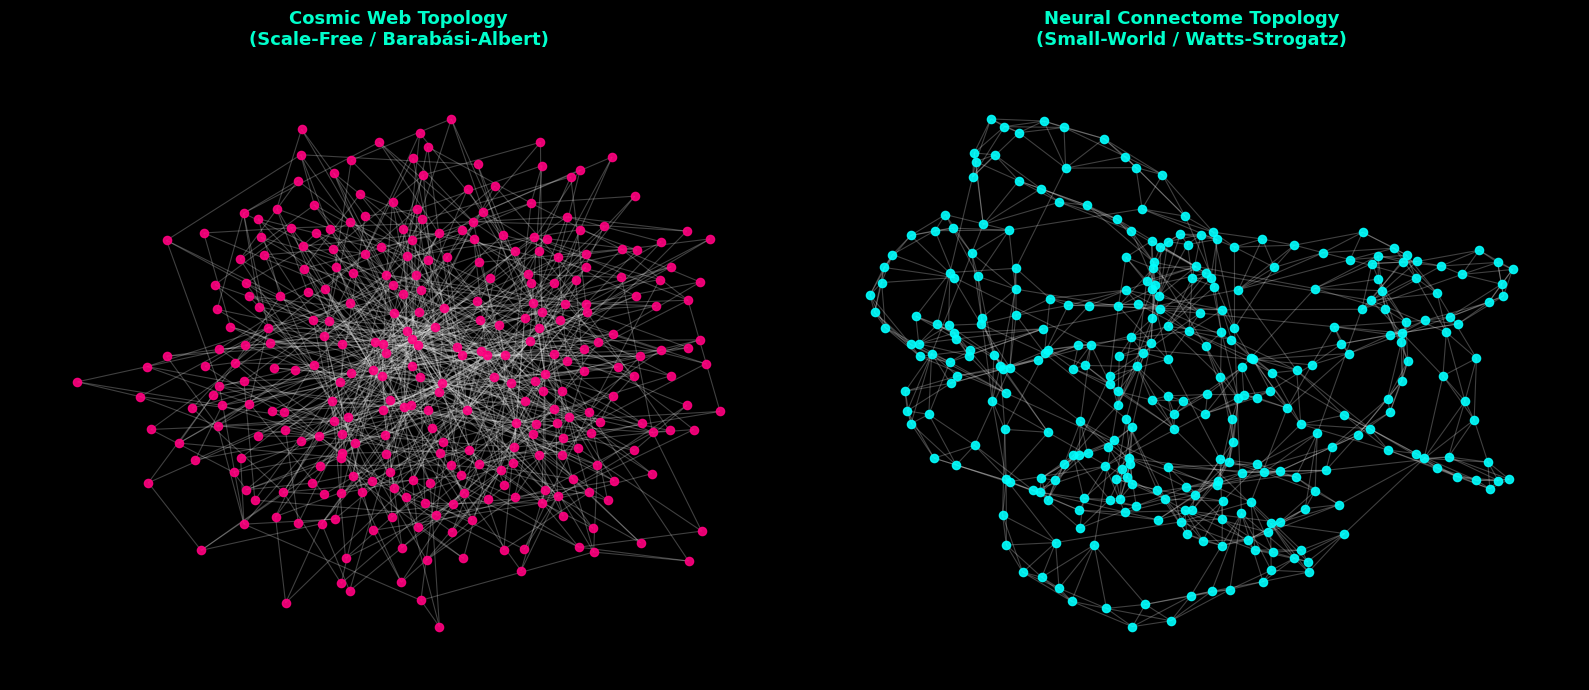

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# 1. PARAMETER DEFINITION
# Scale-free properties for Cosmic Web and Small-world properties for Neural Connectomes
N = 300       # Number of nodes
m_ba = 3      # Number of edges to attach from a new node to existing nodes (Barabási-Albert)
k_ws = 6      # Each node is connected to k nearest neighbors in ring topology (Watts-Strogatz)
p_ws = 0.05   # Probability of rewiring each edge (Watts-Strogatz)

# 2. NETWORK GENERATION
# Cosmic Web Simulation (Scale-Free Network Model)
G_cosmic = nx.barabasi_albert_graph(n=N, m=m_ba)

# Human Neural Connectome Simulation (Small-World Network Model)
G_neural = nx.watts_strogatz_graph(n=N, k=k_ws, p=p_ws)

# 3. TOPOLOGICAL METRICS COMPUTATION
def compute_and_print_metrics(graph, network_name):
    """
    Computes and prints fundamental topological metrics of a given network graph.
    """
    num_nodes = graph.number_of_nodes()
    num_edges = graph.number_of_edges()
    avg_degree = sum(dict(graph.degree()).values()) / num_nodes
    clustering_coeff = nx.average_clustering(graph)

    # Handle potentially disconnected graphs safely for path length calculation
    try:
        avg_path_length = nx.average_shortest_path_length(graph)
    except nx.NetworkXUnconnectedGraph:
        largest_cc = max(nx.connected_components(graph), key=len)
        subgraph = graph.subgraph(largest_cc)
        avg_path_length = nx.average_shortest_path_length(subgraph)

    print(f"==========================================")
    print(f" SYSTEM ANALYSIS: {network_name}")
    print(f"==========================================")
    print(f"• Nodes (|V|): {num_nodes}")
    print(f"• Edges (|E|): {num_edges}")
    print(f"• Average Degree (<k>): {avg_degree:.4f}")
    print(f"• Clustering Coefficient (C): {clustering_coeff:.4f}")
    print(f"• Average Shortest Path Length (L): {avg_path_length:.4f}\n")

    return clustering_coeff, avg_path_length

# Execute metrics computation
metrics_cosmic = compute_and_print_metrics(G_cosmic, "Cosmic Web Simulation (Barabási-Albert)")
metrics_neural = compute_and_print_metrics(G_neural, "Human Neural Connectome (Watts-Strogatz)")

# 4. PUBLICATION-READY VISUALIZATION (Dark Themed Dual-Panel Plot)
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Generate spring layouts for consistent spatial distribution
pos_cosmic = nx.spring_layout(G_cosmic, seed=42)
pos_neural = nx.spring_layout(G_neural, seed=42)

# Panel 1: Cosmic Web Topology
axes[0].set_title("Cosmic Web Topology\n(Scale-Free / Barabási-Albert)", fontsize=13, fontweight='bold', color='#00ffcc', pad=15)
nx.draw_networkx_nodes(G_cosmic, pos_cosmic, ax=axes[0], node_size=35, node_color='#ff007f', alpha=0.9)
nx.draw_networkx_edges(G_cosmic, pos_cosmic, ax=axes[0], alpha=0.25, edge_color='#ffffff', width=0.8)
axes[0].axis('off')

# Panel 2: Neural Connectome Topology
axes[1].set_title("Neural Connectome Topology\n(Small-World / Watts-Strogatz)", fontsize=13, fontweight='bold', color='#00ffcc', pad=15)
nx.draw_networkx_nodes(G_neural, pos_neural, ax=axes[1], node_size=35, node_color='#00ffff', alpha=0.9)
nx.draw_networkx_edges(G_neural, pos_neural, ax=axes[1], alpha=0.25, edge_color='#ffffff', width=0.8)
axes[1].axis('off')

# Final adjustments and export
plt.tight_layout()
plt.savefig('neuro_cosmic_topology_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
